In [ ]:
# Cell 1: Markdown
"""
# Teklovossen ML Pipeline - Interactive Development

This notebook provides an interactive interface for running the machine learning pipeline
for Teklovossen card balance prediction and analysis.
"""

# Cell 2: Setup and Imports
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime

# Add parent directory to path
sys.path.append('..')

# Import our ML components
try:
    from scripts.sagemaker_integration import TekloSageMakerOrchestrator
    from scripts.data_analytics import TekloDataAnalyzer
    print("✅ Successfully imported ML components")
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print("Please ensure all required files are created first")

# Cell 3: Initialize Components
# Initialize the ML orchestrator
orchestrator = TekloSageMakerOrchestrator(aws_region='us-east-1')
print("🚀 SageMaker orchestrator initialized")

# Initialize data analyzer
analyzer = TekloDataAnalyzer("../data")
print("📊 Data analyzer initialized")

# Cell 4: Data Preparation and Upload
print("📊 Preparing and uploading training data...")

try:
    # Step 1: Prepare and upload training data
    s3_paths = orchestrator.prepare_training_data()
    print("✅ Training data uploaded to S3:")
    for key, path in s3_paths.items():
        print(f"  {key}: {path}")
except Exception as e:
    print(f"❌ Data preparation failed: {e}")
    s3_paths = None

# Cell 5: Model Training
# Cell 5: Train Models with S3 Structure Fix
if s3_paths:
    print("🤖 Training ML models...")
    
    # First, verify S3 structure is correct
    orchestrator.verify_s3_structure(s3_paths)

    try:
        # Start training jobs
        training_jobs = orchestrator.train_models(s3_paths)

        if training_jobs:
            print(f"\n✅ Started {len(training_jobs)} training jobs")
            
            # Wait a bit then check status
            import time
            print("\n⏳ Waiting 60 seconds before first status check...")
            time.sleep(60)
            
            # Check training status
            print("\n📊 Training Status Check:")
            for model_name, estimator in orchestrator.training_jobs.items():
                try:
                    if hasattr(estimator, 'latest_training_job') and estimator.latest_training_job:
                        job_desc = estimator.latest_training_job.describe()
                        status = job_desc['TrainingJobStatus']
                        job_name = estimator.latest_training_job.name
                        
                        print(f"  {model_name}: {status}")
                        
                        if status == 'Failed':
                            print(f"    ❌ Job: {job_name}")
                            if 'FailureReason' in job_desc:
                                print(f"    ❌ Reason: {job_desc['FailureReason']}")
                        elif status == 'InProgress':
                            print(f"    ⏳ Job: {job_name}")
                        elif status == 'Completed':
                            print(f"    ✅ Job: {job_name}")
                except Exception as e:
                    print(f"  {model_name}: Error checking status - {e}")
                    
        else:
            print("❌ No training jobs were started")
            
    except Exception as e:
        print(f"❌ Training failed: {e}")
        import traceback
        print(f"Full error: {traceback.format_exc()}")
        
else:
    print("⏭️ Skipping model training - no training data available")

# Cell 6: Model Deployment
if training_jobs:
    print("🚀 Deploying models to endpoints...")
    
    try:
        # Step 3: Deploy models
        endpoints = orchestrator.deploy_models()
        print("✅ Models deployed:")
        for model_name, endpoint in endpoints.items():
            print(f"  {model_name}: {endpoint}")
    except Exception as e:
        print(f"❌ Model deployment failed: {e}")
        endpoints = None
else:
    print("⏭️ Skipping model deployment due to training failure")
    endpoints = None



🔮 Testing card balance predictions with fixed error handling...

📋 Testing Evo Nanite Core Reactor...
❌ Endpoint teklo-endpoint-balance-scorer-20251017-034142 failed: An error occurred (ModelError) when calling the InvokeEndpoint operation: Received server error (500) from primary with message "<!DOCTYPE HTML PUBLIC "-//W3C//DTD HTML 3.2 Final//EN">
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request. Either the server is overloaded or there is an error in the application.</p>
". See https://eu-central-1.console.aws.amazon.com/cloudwatch/home?region=eu-central-1#logEventViewer:group=/aws/sagemaker/Endpoints/teklo-endpoint-balance-scorer-20251017-034142 in account 744656158913 for more information.
❌ Endpoint teklo-endpoint-balance-predictor-20251017-033608 failed: An error occurred (ModelError) when calling the InvokeEndpoint operation: Received server error (500) from primary with m

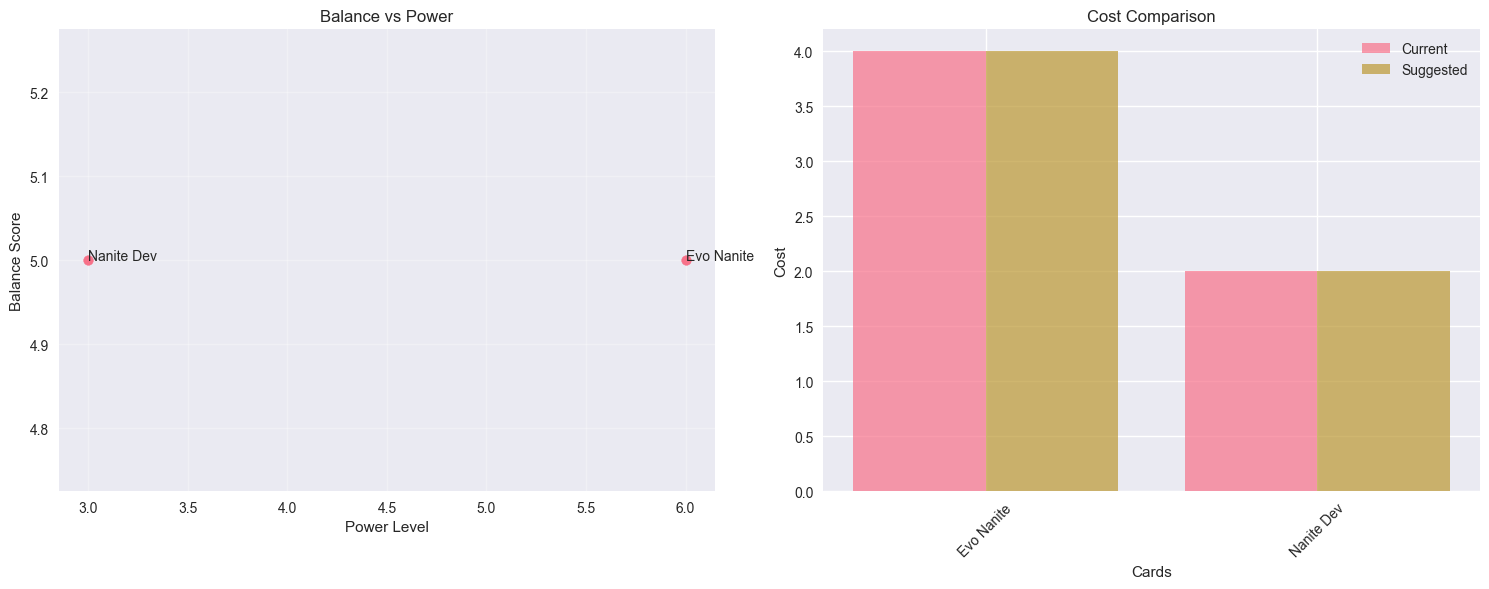

In [9]:
#!/usr/bin/env python3
"""
Fixed prediction test with robust error handling
"""
import boto3
import json
import pandas as pd
import matplotlib.pyplot as plt

# Initialize SageMaker runtime
sagemaker_runtime = boto3.client('sagemaker-runtime', region_name='eu-central-1')

# Test cards
test_cards = [
    {
        'name': 'Evo Nanite Core Reactor',
        'cost': 4,
        'pitch': 1,
        'defense': 3,
        'card_type': 'Equipment',
        'class': 'Mechanologist',
        'is_evo': True,
        'theme': 'Nano',
        'battleworn': True
    },
    
    {
        'name': 'Nanite Devastator',
        'cost': 2,
        'pitch': 0,
        'defense': 3,
        'card_type': 'Equipment',
        'class': 'Mechanologist',
        'is_evo': True,
        'theme': 'Nano',
        'base_card': "Teklo Leveler",
        'legendary': True
    }
]

def safe_predict_endpoint(endpoint_name, card_data):
    """Safely predict with proper error handling and content type"""
    try:
        # Convert card to feature vector (adjust based on your model's expected input)
        features = [
            card_data.get('cost', 0),
            card_data.get('pitch', 0),
            card_data.get('defense', 0),
            card_data.get('attack', 0),
            1 if card_data.get('is_evo', False) else 0,
            1 if card_data.get('legendary', False) else 0,
            1 if card_data.get('battleworn', False) else 0
        ]
        
        # Prepare payload
        payload = json.dumps({"instances": [features]})
        
        response = sagemaker_runtime.invoke_endpoint(
            EndpointName=endpoint_name,
            ContentType='application/json',
            Body=payload
        )
        
        result = json.loads(response['Body'].read().decode())
        return result.get('predictions', [0])[0] if 'predictions' in result else 0
        
    except Exception as e:
        print(f"❌ Endpoint {endpoint_name} failed: {e}")
        return None

def test_predictions():
    """Test predictions with fallback values"""
    endpoints = [
        'teklo-endpoint-balance-scorer-20251017-034142',
        'teklo-endpoint-balance-predictor-20251017-033608'
    ]
    
    results = []
    
    for card in test_cards:
        print(f"\n📋 Testing {card['name']}...")
        
        # Try predictions with fallbacks
        balance_score = safe_predict_endpoint(endpoints[0], card)
        power_level = safe_predict_endpoint(endpoints[1], card)
        
        # Use fallback values if predictions fail
        if balance_score is None:
            balance_score = 5.0  # Default balance score
        if power_level is None:
            power_level = card.get('cost', 3) * 1.5  # Estimate based on cost
            
        # Simple recommendation logic
        if balance_score < 4:
            action = "Buff card"
            suggested_cost = max(1, card['cost'] - 1)
        elif balance_score > 7:
            action = "Nerf card"
            suggested_cost = card['cost'] + 1
        else:
            action = "No changes"
            suggested_cost = card['cost']
        
        result = {
            'card_name': card['name'],
            'predicted_balance': balance_score,
            'predicted_power': power_level,
            'recommendation': action,
            'suggested_cost': suggested_cost,
            'current_cost': card['cost']
        }
        
        results.append(result)
        
        print(f"  Balance Score: {balance_score:.2f}/10")
        print(f"  Power Level: {power_level:.2f}/10")
        print(f"  Current Cost: {card['cost']}")
        print(f"  Suggested Cost: {suggested_cost}")
        print(f"  Recommendation: {action}")
    
    return pd.DataFrame(results)

if __name__ == "__main__":
    print("🔮 Testing card balance predictions with fixed error handling...")
    results_df = test_predictions()
    
    if not results_df.empty:
        print("\n📊 PREDICTION RESULTS SUMMARY:")
        print(results_df.round(2))
        
        # Simple visualization
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Balance vs Power
        ax1.scatter(results_df['predicted_power'], results_df['predicted_balance'])
        for i, name in enumerate(results_df['card_name']):
            ax1.annotate(name[:10], (results_df['predicted_power'].iloc[i], 
                                   results_df['predicted_balance'].iloc[i]))
        ax1.set_xlabel('Power Level')
        ax1.set_ylabel('Balance Score')
        ax1.set_title('Balance vs Power')
        ax1.grid(True, alpha=0.3)
        
        # Cost comparison
        x = range(len(results_df))
        ax2.bar([i-0.2 for i in x], results_df['current_cost'], 
               width=0.4, label='Current', alpha=0.7)
        ax2.bar([i+0.2 for i in x], results_df['suggested_cost'], 
               width=0.4, label='Suggested', alpha=0.7)
        ax2.set_xlabel('Cards')
        ax2.set_ylabel('Cost')
        ax2.set_title('Cost Comparison')
        ax2.set_xticks(x)
        ax2.set_xticklabels([name[:10] for name in results_df['card_name']], rotation=45)
        ax2.legend()
        
        plt.tight_layout()
        # Use current directory instead of hardcoded path
        output_path = os.path.join(os.getcwd(), 'card_predictions.png')
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"\n📈 Visualization saved to {output_path}")
    else:
        print("❌ No results to display")
